# Simulated RPKM plots

This notebook plots only the `mean_sim_rpkm` column for the 6-4PP and CPD datasets.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
BASE_DIR = Path("/cta/users/guneyn23/rpkm")

DATASETS = {
    "6-4PP": {
        "files": [
            BASE_DIR / "64_rpkm/ATAC_mean_normalized_rpkm.tsv",
            BASE_DIR / "64_rpkm/H3K9me3_mean_normalized_rpkm.tsv",
            BASE_DIR / "64_rpkm/H3K27me3_mean_normalized_rpkm.tsv",
        ],
        "output": BASE_DIR / "64_rpkm/64_simulated_rpkm.png",
        "title": "Simulated 6-4PP Damage Distribution Around Peak Centers",
    },
    "CPD": {
        "files": [
            BASE_DIR / "CPD_rpkm/atac_rpkm/mean_rpkm_ratio.tsv",
            BASE_DIR / "CPD_rpkm/close_rpkm/H3K9me3_mean_rpkm_ratio.tsv",
            BASE_DIR / "CPD_rpkm/close_rpkm/H3K27me3_mean_rpkm_ratio.tsv",
        ],
        "output": BASE_DIR / "CPD_rpkm/CPD_simulated_rpkm.png",
        "title": "Simulated CPD Damage Distribution Around Peak Centers",
    },
}

In [3]:
def plot_sim_rpkm(files, output, title):
    labels = ("ATAC", "H3K9me3", "H3K27me3")
    colors = ("blue", "red", "green")
    tables = [pd.read_csv(path, sep="\t") for path in files]

    fig, ax = plt.subplots(figsize=(10, 5))
    for table, label, color in zip(tables, labels, colors):
        x = np.linspace(-10, 10, len(table))
        ax.plot(x, table["mean_sim_rpkm"], color=color, label=label)

    maximum_value = max(table["mean_sim_rpkm"].max() for table in tables)
    ax.axvline(0, color="gray", linestyle="--")
    ax.text(0, maximum_value, "Peak center", color="gray", ha="left", va="bottom")
    ax.set(
        xlabel="Distance from peak center (kb)",
        ylabel="Mean simulated RPKM",
        title=title,
        xlim=(-10, 10),
        xticks=[-10, -5, 0, 5, 10],
    )
    ax.legend()
    fig.tight_layout()
    fig.savefig(output, dpi=300)
    plt.show()
    return output

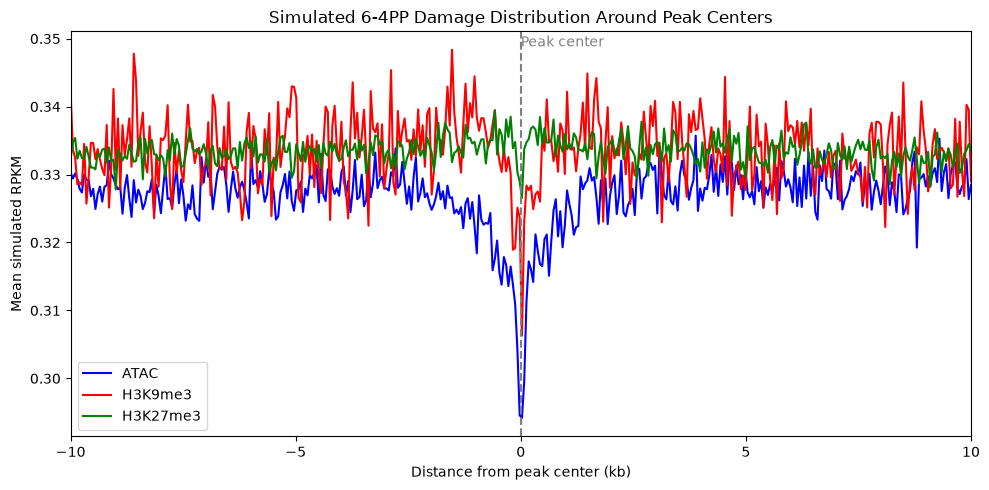

6-4PP simulated plot written to: /cta/users/guneyn23/rpkm/64_rpkm/64_simulated_rpkm.png


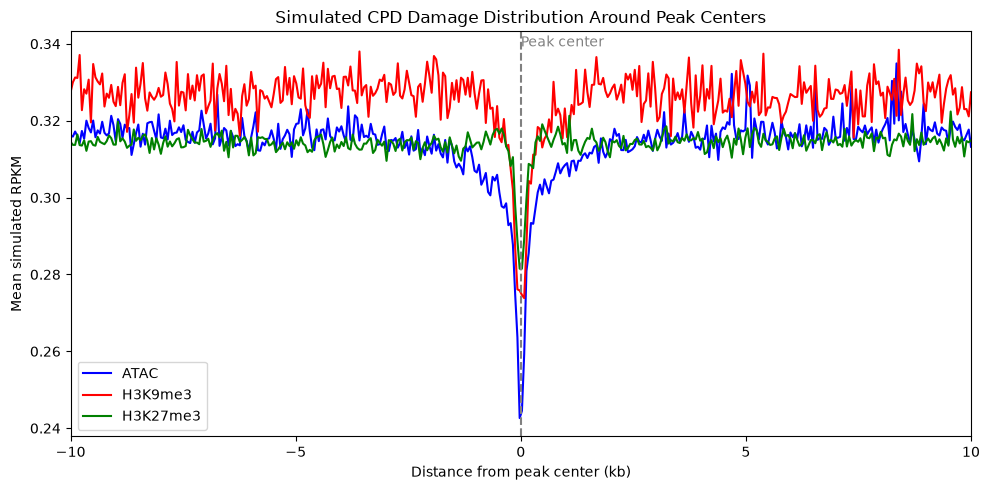

CPD simulated plot written to: /cta/users/guneyn23/rpkm/CPD_rpkm/CPD_simulated_rpkm.png


In [4]:
for dataset_name, config in DATASETS.items():
    output = plot_sim_rpkm(**config)
    print(f"{dataset_name} simulated plot written to: {output}")